In [1]:
# --- 1) Setup ---
from pathlib import Path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

DATA_PATH = Path("data/input/ineatlas/census_2021_tract.csv")
assert DATA_PATH.exists(), f"File not found: {DATA_PATH}"

print("File:", DATA_PATH)
print("Size (MB):", round(DATA_PATH.stat().st_size / (1024**2), 2))

File: data/input/ineatlas/census_2021_tract.csv
Size (MB): 8.38


In [2]:
# --- 2) Peek columns + sample ---
cols = pd.read_csv(DATA_PATH, nrows=0).columns.tolist()
sample = pd.read_csv(DATA_PATH, nrows=5)

print("Number of columns:", len(cols))
print(cols)
display(sample)

Number of columns: 41
['tract_code', 'district_code', 'mun_code', 'prov_code', 'total_pop', 'pct_female', 'pct_male', 'mean_age', 'pct_under16', 'pct_16to64', 'pct_over64', 'pct_foreign', 'pct_foreign_born', 'pct_higher_ed_enrolled', 'pct_university_enrolled', 'pct_higher_ed_completed', 'unemployment_rate', 'employment_rate', 'activity_rate', 'pct_disability_pension', 'pct_retirement_pension', 'pct_other_inactive', 'pct_student', 'pct_single', 'pct_married', 'pct_widowed', 'pct_marital_unknown', 'pct_divorced_separated', 'total_dwellings', 'primary_dwellings', 'secondary_dwellings', 'owned_dwellings', 'rented_dwellings', 'other_tenure_dwellings', 'total_households', 'hh_size1', 'hh_size2', 'hh_size3', 'hh_size4', 'hh_size5plus', 'prov_name']


,tract_code,district_code,mun_code,prov_code,total_pop,pct_female,pct_male,mean_age,pct_under16,pct_16to64,...,owned_dwellings,rented_dwellings,other_tenure_dwellings,total_households,hh_size1,hh_size2,hh_size3,hh_size4,hh_size5plus,prov_name
0,400101001,400101,4001,4,1260,0.4857,0.5143,49.4994,0.1048,0.6008,...,394,80,94,568,199,182,90,73,24,Almería
1,400201001,400201,4002,4,1212,0.4719,0.5281,49.4636,0.0891,0.6287,...,429,89,65,583,241,165,93,67,17,Almería
2,400301001,400301,4003,4,869,0.5086,0.4914,45.0789,0.1208,0.6789,...,256,29,28,313,69,86,64,57,37,Almería
3,400301002,400301,4003,4,1781,0.5014,0.4986,40.2112,0.1791,0.6912,...,535,38,53,626,119,156,139,154,58,Almería
4,400301003,400301,4003,4,2235,0.5087,0.4913,38.1048,0.1884,0.7051,...,701,82,78,861,225,215,187,174,60,Almería


In [3]:
# --- 3) Row count (streaming, low memory) ---
with open(DATA_PATH, "rb") as f:
    n_rows = sum(1 for _ in f) - 1 # minus header
print("Number of rows:", n_rows)

Number of rows: 36333


In [4]:
# --- 4) Load full dataframe (usually fine for this file, but still low_memory=False) ---
df = pd.read_csv(DATA_PATH, low_memory=False)
print(df.shape)
df.head(3)

(36333, 41)


,tract_code,district_code,mun_code,prov_code,total_pop,pct_female,pct_male,mean_age,pct_under16,pct_16to64,...,owned_dwellings,rented_dwellings,other_tenure_dwellings,total_households,hh_size1,hh_size2,hh_size3,hh_size4,hh_size5plus,prov_name
0,400101001,400101,4001,4,1260,0.4857,0.5143,49.4994,0.1048,0.6008,...,394.0,80.0,94.0,568.0,199.0,182.0,90.0,73.0,24.0,Almería
1,400201001,400201,4002,4,1212,0.4719,0.5281,49.4636,0.0891,0.6287,...,429.0,89.0,65.0,583.0,241.0,165.0,93.0,67.0,17.0,Almería
2,400301001,400301,4003,4,869,0.5086,0.4914,45.0789,0.1208,0.6789,...,256.0,29.0,28.0,313.0,69.0,86.0,64.0,57.0,37.0,Almería


In [5]:
# --- 5) Basic data quality ---
# Missing values
missing = (
    df.isna()
      .sum()
      .sort_values(ascending=False)
      .to_frame("missing_count")
)
missing["missing_pct"] = (missing["missing_count"] / len(df) * 100).round(2)
display(missing.head(20))

# Duplicates (full row)
print("Duplicate full rows:", df.duplicated().sum())

,missing_count,missing_pct
pct_under16,1363,3.75
pct_male,1363,3.75
mean_age,1363,3.75
pct_female,1363,3.75
pct_higher_ed_enrolled,1363,3.75
pct_foreign_born,1363,3.75
pct_foreign,1363,3.75
pct_over64,1363,3.75
pct_16to64,1363,3.75
pct_widowed,1363,3.75


Duplicate full rows: 0


In [6]:
# --- 6) Candidate key check (adjust names if needed) ---
# Try common key column names dynamically
possible_keys = [
    ["prov_code", "mun_code", "district_code", "tract_code"],
    ["province_code", "municipality_code", "district_code", "tract_code"],
    ["cod_prov", "cod_mun", "cod_dist", "cod_sec"],
]

found_key = None
for k in possible_keys:
    if all(c in df.columns for c in k):
        found_key = k
        break

if found_key:
    print("Using key:", found_key)
    dup_key = df.duplicated(subset=found_key).sum()
    print("Duplicate key rows:", dup_key)
else:
    print("No standard tract key set found. Inspect columns and set key manually.")

Using key: ['prov_code', 'mun_code', 'district_code', 'tract_code']
Duplicate key rows: 0


In [7]:
# 1) Provinces count (Spain mainland+islands+Ceuta/Melilla should be 52 provinces)
n_prov = df["prov_code"].nunique()
print("Unique provinces:", n_prov)
print("Province codes:", sorted(df["prov_code"].astype(int).unique())[:10], "...")

# 2) Municipality count (expected around 8k+; exact changes over time)
n_mun = df[["prov_code","mun_code"]].drop_duplicates().shape[0]
print("Unique municipalities:", n_mun)

# 3) Check presence of Ceuta and Melilla (52 and 53)
prov_codes = set(df["prov_code"].astype(int).unique())
print("Has Ceuta (52):", 52 in prov_codes)
print("Has Melilla (53):", 53 in prov_codes)

Unique provinces: 52
Province codes: [np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8), np.int64(9), np.int64(10)] ...
Unique municipalities: 8131
Has Ceuta (52): True
Has Melilla (53): False


In [8]:
expected = {
    "Álava","Albacete","Alicante/Alacant","Almería","Asturias","Ávila","Badajoz","Illes Balears",
    "Barcelona","Burgos","Cáceres","Cádiz","Cantabria","Castellón/Castelló","Ciudad Real","Córdoba",
    "A Coruña","Cuenca","Girona","Granada","Guadalajara","Gipuzkoa","Huelva","Huesca","Jaén","León",
    "Lleida","Lugo","Madrid","Málaga","Murcia","Navarra","Ourense","Palencia","Las Palmas","Pontevedra",
    "La Rioja","Salamanca","Santa Cruz de Tenerife","Segovia","Sevilla","Soria","Tarragona","Teruel",
    "Toledo","Valencia/València","Valladolid","Bizkaia","Zamora","Zaragoza","Ceuta","Melilla"
}

actual = set(df["prov_name"].dropna().unique())
print("Province names in dataset:", len(actual))
print("Missing vs expected:", sorted(expected - actual))
print("Extra vs expected:", sorted(actual - expected)[:20])

Province names in dataset: 52
Missing vs expected: ['A Coruña', 'Illes Balears', 'La Rioja', 'Las Palmas', 'Álava']
Extra vs expected: ['Araba/Álava', 'Balears, Illes', 'Coruña, A', 'Palmas, Las', 'Rioja, La']


In [9]:
sns.set_theme(style="whitegrid")

df = pd.read_csv(DATA_PATH, low_memory=False)
df["prov_code_int"] = df["prov_code"].astype(int)

# Region mapping (CCAA) from province code
prov_to_region = {
    1:"País Vasco",2:"Castilla-La Mancha",3:"Comunitat Valenciana",4:"Andalucía",5:"Castilla y León",
    6:"Extremadura",7:"Illes Balears",8:"Cataluña",9:"Castilla y León",10:"Extremadura",
    11:"Andalucía",12:"Comunitat Valenciana",13:"Castilla-La Mancha",14:"Andalucía",15:"Galicia",
    16:"Castilla-La Mancha",17:"Cataluña",18:"Andalucía",19:"Castilla-La Mancha",20:"País Vasco",
    21:"Andalucía",22:"Aragón",23:"Andalucía",24:"Castilla y León",25:"Cataluña",26:"La Rioja",
    27:"Galicia",28:"Comunidad de Madrid",29:"Andalucía",30:"Región de Murcia",31:"Navarra",
    32:"Galicia",33:"Asturias",34:"Castilla y León",35:"Canarias",36:"Galicia",37:"Castilla y León",
    38:"Canarias",39:"Cantabria",40:"Castilla y León",41:"Andalucía",42:"Castilla y León",
    43:"Cataluña",44:"Aragón",45:"Castilla-La Mancha",46:"Comunitat Valenciana",47:"Castilla y León",
    48:"País Vasco",49:"Castilla y León",50:"Aragón",51:"Ceuta",52:"Melilla"
}
df["region"] = df["prov_code_int"].map(prov_to_region)

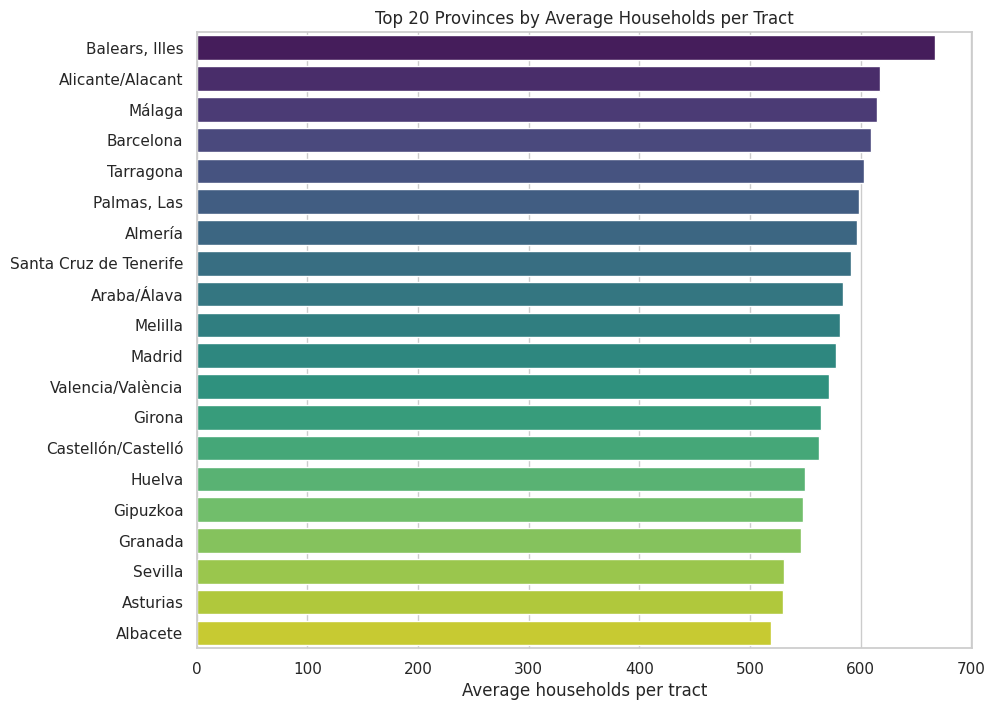

In [10]:
prov_size = (
    df.groupby("prov_name", as_index=False)
      .agg(
          tracts=("tract_code", "count"),
          avg_hh_per_tract=("total_households", "mean"),
          median_hh_per_tract=("total_households", "median"),
          avg_pop_per_tract=("total_pop", "mean")
      )
      .sort_values("avg_hh_per_tract", ascending=False)
)

top_n = 20
plt.figure(figsize=(10,8))
sns.barplot(
    data=prov_size.head(top_n),
    y="prov_name",
    x="avg_hh_per_tract",
    hue="prov_name",
    palette="viridis",
    legend=False
)
plt.title(f"Top {top_n} Provinces by Average Households per Tract")
plt.xlabel("Average households per tract")
plt.ylabel("")
plt.show()

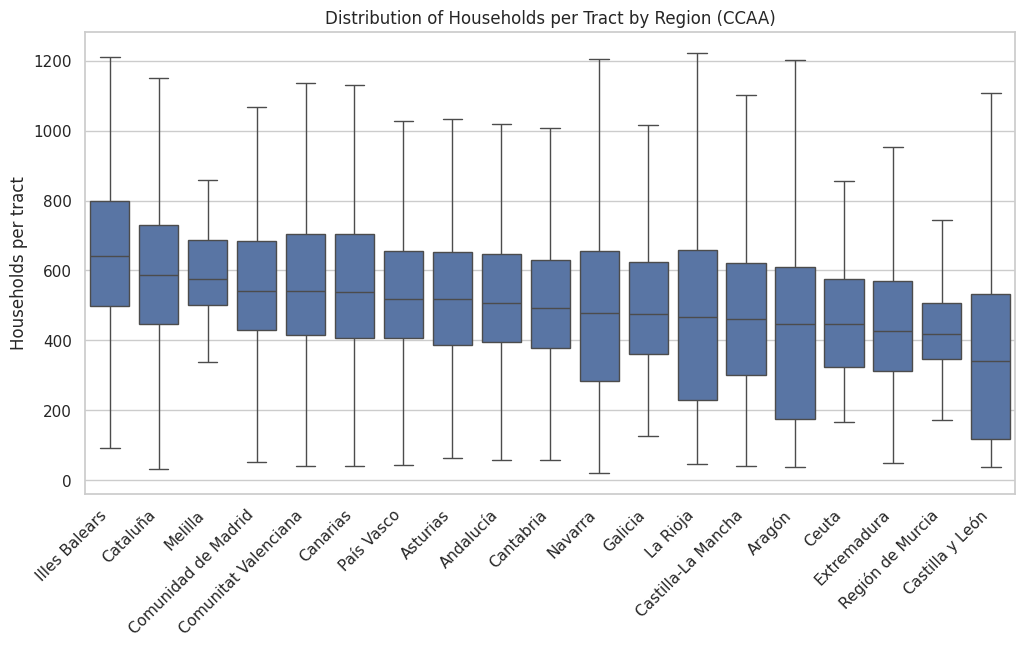

In [11]:
plot_reg = df.dropna(subset=["region", "total_households"]).copy()

plt.figure(figsize=(12,6))
order = (
    plot_reg.groupby("region")["total_households"]
    .median()
    .sort_values(ascending=False)
    .index
)
sns.boxplot(
    data=plot_reg,
    x="region",
    y="total_households",
    order=order,
    showfliers=False
)
plt.xticks(rotation=45, ha="right")
plt.title("Distribution of Households per Tract by Region (CCAA)")
plt.xlabel("")
plt.ylabel("Households per tract")
plt.show()

In [12]:
region_summary = (
    df.groupby("region", as_index=False)
      .agg(
          tracts=("tract_code","count"),
          avg_hh_per_tract=("total_households","mean"),
          median_hh_per_tract=("total_households","median"),
          avg_pop_per_tract=("total_pop","mean"),
      )
      .sort_values("avg_hh_per_tract", ascending=False)
)

display(region_summary.round(1))

,region,tracts,avg_hh_per_tract,median_hh_per_tract,avg_pop_per_tract
13,Illes Balears,662,667.0,642.5,1787.6
3,Canarias,1382,594.9,539.0,1576.6
7,Cataluña,5083,591.7,588.0,1524.7
10,Comunitat Valenciana,3473,586.3,541.5,1459.2
15,Melilla,44,581.3,577.0,1964.8
9,Comunidad de Madrid,4417,577.6,542.0,1522.9
0,Andalucía,5995,541.1,507.0,1415.3
17,País Vasco,1714,536.5,519.0,1290.9
2,Asturias,843,529.7,518.0,1200.6
4,Cantabria,467,512.2,493.0,1252.1


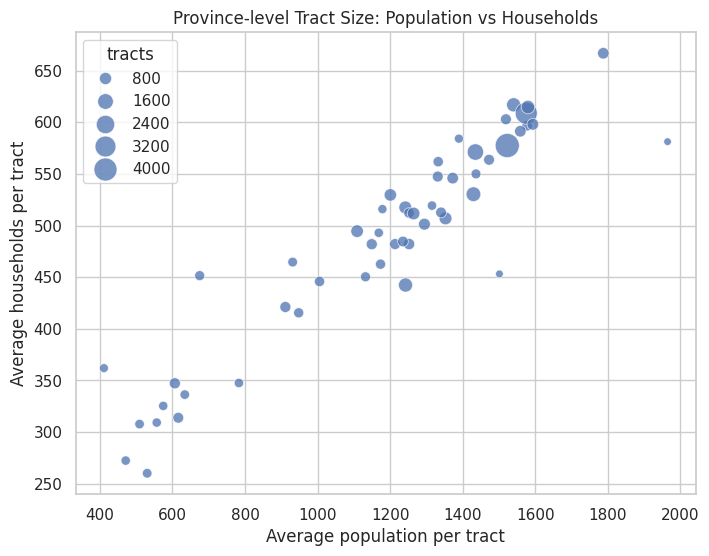

In [13]:
prov_scatter = (
    df.groupby("prov_name", as_index=False)
      .agg(
          avg_hh_per_tract=("total_households","mean"),
          avg_pop_per_tract=("total_pop","mean"),
          tracts=("tract_code","count")
      )
)

plt.figure(figsize=(8,6))
sns.scatterplot(
    data=prov_scatter,
    x="avg_pop_per_tract",
    y="avg_hh_per_tract",
    size="tracts",
    sizes=(30, 300),
    alpha=0.75
)
plt.title("Province-level Tract Size: Population vs Households")
plt.xlabel("Average population per tract")
plt.ylabel("Average households per tract")
plt.show()

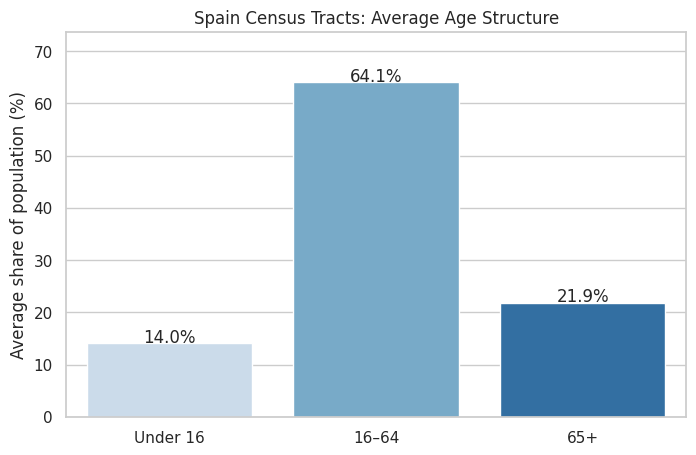

In [14]:
age_cols = ["pct_under16", "pct_16to64", "pct_over64"]
age_means = df[age_cols].mean(skipna=True) * 100

plt.figure(figsize=(8,5))
labels = ["Under 16", "16–64", "65+"]
sns.barplot(x=labels, y=age_means.values, hue=labels, palette="Blues", legend=False)

plt.ylabel("Average share of population (%)")
plt.title("Spain Census Tracts: Average Age Structure")
for i, v in enumerate(age_means.values):
    plt.text(i, v + 0.2, f"{v:.1f}%", ha="center")
plt.ylim(0, max(age_means.values)*1.15)
plt.show()

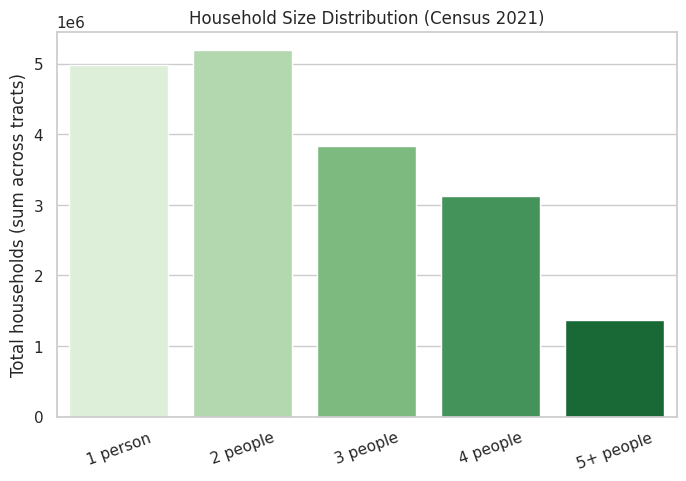

In [15]:
hh_cols = ["hh_size1", "hh_size2", "hh_size3", "hh_size4", "hh_size5plus"]
hh_sum = df[hh_cols].sum(skipna=True)

plt.figure(figsize=(8,5))
labels = ["1 person","2 people","3 people","4 people","5+ people"]
sns.barplot(x=labels, y=hh_sum.values, hue=labels, palette="Greens", legend=False)
plt.ylabel("Total households (sum across tracts)")
plt.title("Household Size Distribution (Census 2021)")
plt.xticks(rotation=20)
plt.show()

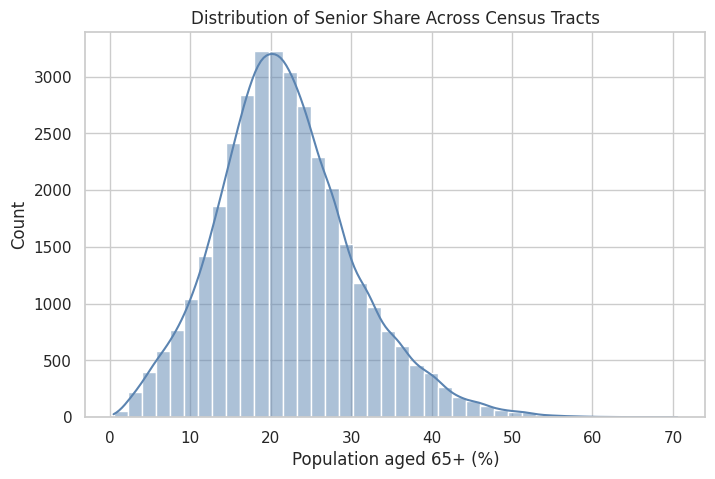

In [16]:
plt.figure(figsize=(8,5))
sns.histplot(df["pct_over64"]*100, bins=40, kde=True, color="#5B84B1")
plt.xlabel("Population aged 65+ (%)")
plt.title("Distribution of Senior Share Across Census Tracts")
plt.show()

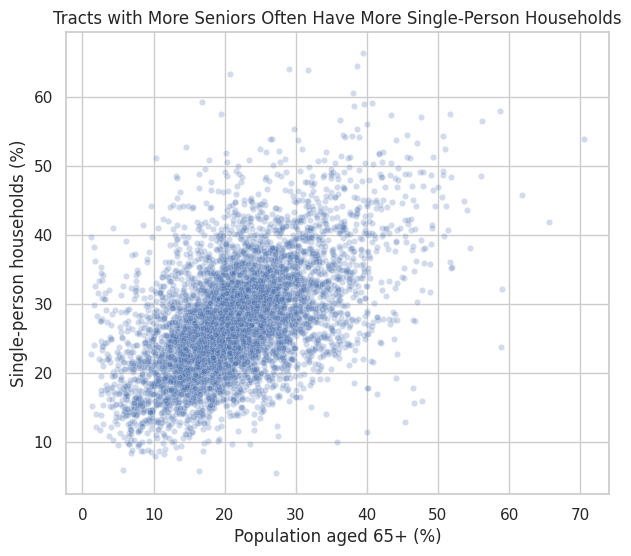

Correlation: 0.542


In [17]:
tmp = df[["hh_size1", "total_households", "pct_over64"]].copy()
tmp = tmp.dropna()
tmp = tmp[tmp["total_households"] > 0]
tmp["single_household_pct"] = tmp["hh_size1"] / tmp["total_households"] * 100
tmp["senior_pct"] = tmp["pct_over64"] * 100

plt.figure(figsize=(7,6))
sns.scatterplot(data=tmp.sample(min(6000, len(tmp)), random_state=42),
                x="senior_pct", y="single_household_pct", alpha=0.25, s=20)
plt.xlabel("Population aged 65+ (%)")
plt.ylabel("Single-person households (%)")
plt.title("Tracts with More Seniors Often Have More Single-Person Households")
plt.show()

print("Correlation:", tmp[["senior_pct","single_household_pct"]].corr().iloc[0,1].round(3))

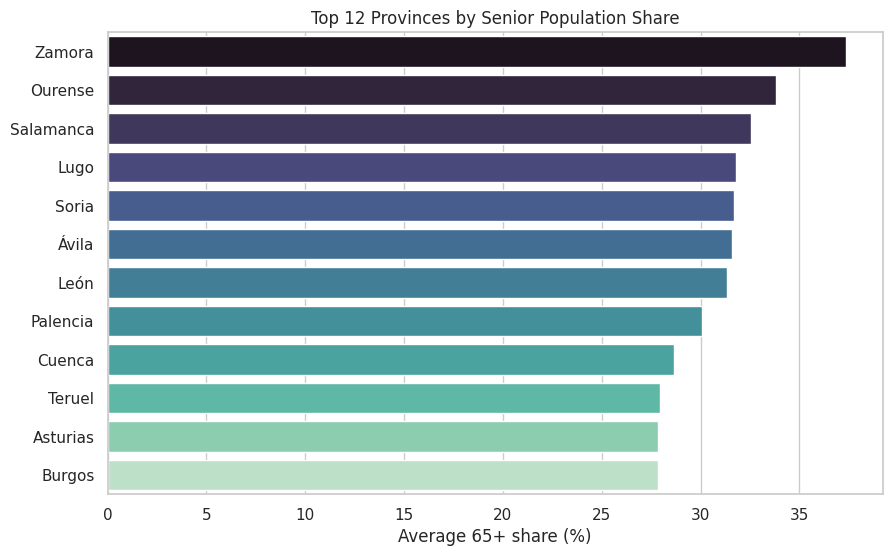

In [18]:
prov = df.groupby("prov_name", dropna=False).agg(
    senior_pct=("pct_over64", "mean"),
    under16_pct=("pct_under16", "mean"),
    single_hh=("hh_size1", "sum"),
    total_hh=("total_households", "sum")
).reset_index()

prov["single_hh_pct"] = prov["single_hh"] / prov["total_hh"] * 100
prov = prov.sort_values("senior_pct", ascending=False)

top_n = 12
plt.figure(figsize=(10,6))

top = prov.head(top_n).copy()
top["senior_pct_100"] = top["senior_pct"] * 100
sns.barplot(
    data=top,
    y="prov_name",
    x="senior_pct_100",
    hue="prov_name",
    palette="mako",
    legend=False
)
plt.xlabel("Average 65+ share (%)")
plt.ylabel("")
plt.title(f"Top {top_n} Provinces by Senior Population Share")
plt.show()

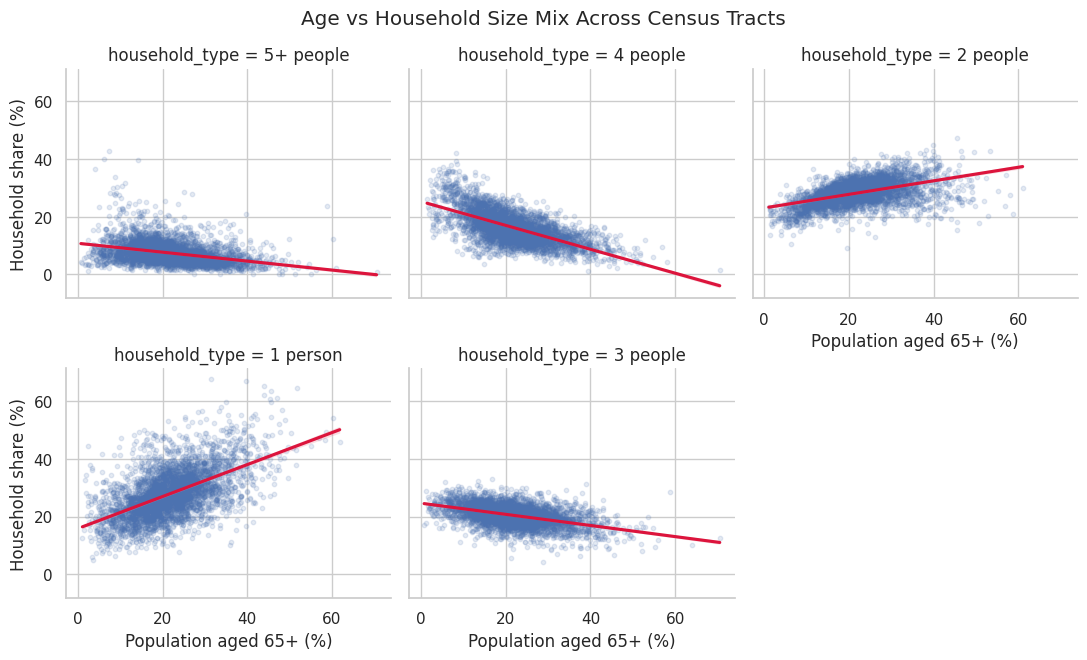

In [19]:
tmp = df[["pct_over64", "total_households", "hh_size1", "hh_size2", "hh_size3", "hh_size4", "hh_size5plus"]].copy()
tmp = tmp.dropna()
tmp = tmp[tmp["total_households"] > 0]

for c in ["hh_size1","hh_size2","hh_size3","hh_size4","hh_size5plus"]:
    tmp[f"{c}_pct"] = tmp[c] / tmp["total_households"] * 100

# Long format for faceted scatterplots
plot_df = tmp.melt(
    id_vars=["pct_over64"],
    value_vars=[f"{c}_pct" for c in ["hh_size1","hh_size2","hh_size3","hh_size4","hh_size5plus"]],
    var_name="household_type",
    value_name="household_share_pct"
)

label_map = {
    "hh_size1_pct": "1 person",
    "hh_size2_pct": "2 people",
    "hh_size3_pct": "3 people",
    "hh_size4_pct": "4 people",
    "hh_size5plus_pct": "5+ people"
}
plot_df["household_type"] = plot_df["household_type"].map(label_map)
plot_df["senior_share_pct"] = plot_df["pct_over64"] * 100

g = sns.lmplot(
    data=plot_df.sample(min(20000, len(plot_df)), random_state=42),
    x="senior_share_pct",
    y="household_share_pct",
    col="household_type",
    col_wrap=3,
    scatter_kws={"alpha":0.15, "s":10},
    line_kws={"color":"crimson"},
    height=3.2,
    aspect=1.15
)
g.set_axis_labels("Population aged 65+ (%)", "Household share (%)")
g.fig.suptitle("Age vs Household Size Mix Across Census Tracts", y=1.03)
plt.show()

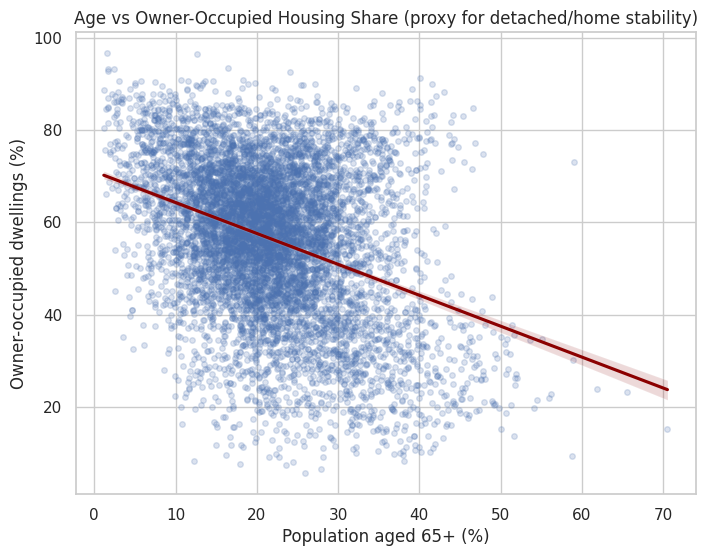

Correlation: -0.364


In [20]:
tmp2 = df[["pct_over64", "owned_dwellings", "total_dwellings"]].copy()
tmp2 = tmp2.dropna()
tmp2 = tmp2[tmp2["total_dwellings"] > 0]
tmp2["owner_occ_pct"] = tmp2["owned_dwellings"] / tmp2["total_dwellings"] * 100
tmp2["senior_share_pct"] = tmp2["pct_over64"] * 100

plt.figure(figsize=(8,6))
sns.regplot(
    data=tmp2.sample(min(8000, len(tmp2)), random_state=42),
    x="senior_share_pct",
    y="owner_occ_pct",
    scatter_kws={"alpha":0.2, "s":16},
    line_kws={"color":"darkred"}
)
plt.xlabel("Population aged 65+ (%)")
plt.ylabel("Owner-occupied dwellings (%)")
plt.title("Age vs Owner-Occupied Housing Share (proxy for detached/home stability)")
plt.show()

print("Correlation:", tmp2[["senior_share_pct", "owner_occ_pct"]].corr().iloc[0,1].round(3))

In [21]:
tmp = df[["hh_size1","total_households","pct_over64","prov_name"]].copy()
tmp = tmp.dropna()
tmp = tmp[tmp["total_households"] > 0]

tmp["single_hh_pct"] = tmp["hh_size1"] / tmp["total_households"] * 100
tmp["family_hh_pct"] = 100 - tmp["single_hh_pct"] # simple complement
tmp["senior_pct"] = tmp["pct_over64"] * 100

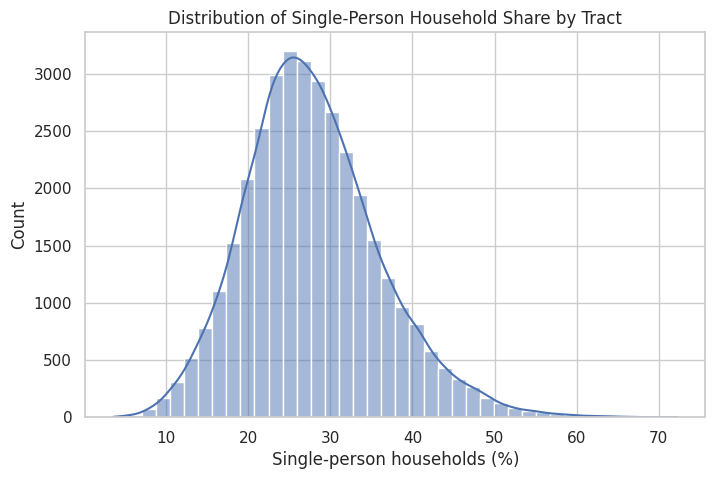

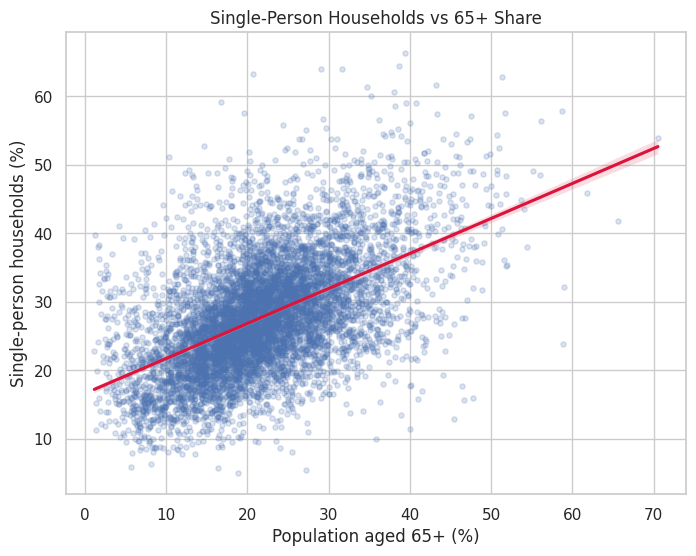

Correlation: 0.542


In [22]:
# 1) Distribution
plt.figure(figsize=(8,5))
sns.histplot(tmp["single_hh_pct"], bins=40, kde=True)
plt.title("Distribution of Single-Person Household Share by Tract")
plt.xlabel("Single-person households (%)")
plt.show()

# 2) Relationship with age
plt.figure(figsize=(8,6))
sns.regplot(
    data=tmp.sample(min(8000, len(tmp)), random_state=42),
    x="senior_pct", y="single_hh_pct",
    scatter_kws={"alpha":0.2, "s":14},
    line_kws={"color":"crimson"}
)
plt.title("Single-Person Households vs 65+ Share")
plt.xlabel("Population aged 65+ (%)")
plt.ylabel("Single-person households (%)")
plt.show()

print("Correlation:", tmp[["senior_pct","single_hh_pct"]].corr().iloc[0,1].round(3))

In [23]:
sns.set_theme(style="white")

# --- Region mapping from INE province code ---
prov_to_region = {
    1:"País Vasco",2:"Castilla-La Mancha",3:"Comunitat Valenciana",4:"Andalucía",5:"Castilla y León",
    6:"Extremadura",7:"Illes Balears",8:"Cataluña",9:"Castilla y León",10:"Extremadura",
    11:"Andalucía",12:"Comunitat Valenciana",13:"Castilla-La Mancha",14:"Andalucía",15:"Galicia",
    16:"Castilla-La Mancha",17:"Cataluña",18:"Andalucía",19:"Castilla-La Mancha",20:"País Vasco",
    21:"Andalucía",22:"Aragón",23:"Andalucía",24:"Castilla y León",25:"Cataluña",26:"La Rioja",
    27:"Galicia",28:"Comunidad de Madrid",29:"Andalucía",30:"Región de Murcia",31:"Navarra",
    32:"Galicia",33:"Asturias",34:"Castilla y León",35:"Canarias",36:"Galicia",37:"Castilla y León",
    38:"Canarias",39:"Cantabria",40:"Castilla y León",41:"Andalucía",42:"Castilla y León",
    43:"Cataluña",44:"Aragón",45:"Castilla-La Mancha",46:"Comunitat Valenciana",47:"Castilla y León",
    48:"País Vasco",49:"Castilla y León",50:"Aragón",51:"Ceuta",52:"Melilla"
}

df["prov_code_int"] = df["prov_code"].astype(int)
df["region"] = df["prov_code_int"].map(prov_to_region)

# metrics to visualize
metrics = {
    "pct_over64": "Age 65+ (%)",
    "employment_rate": "Employment rate (%)",
    "pct_retirement_pension": "Retirement pension share (%)"
}

# convert ratios to %
for c in metrics.keys():
    df[c + "_pct"] = df[c] * 100

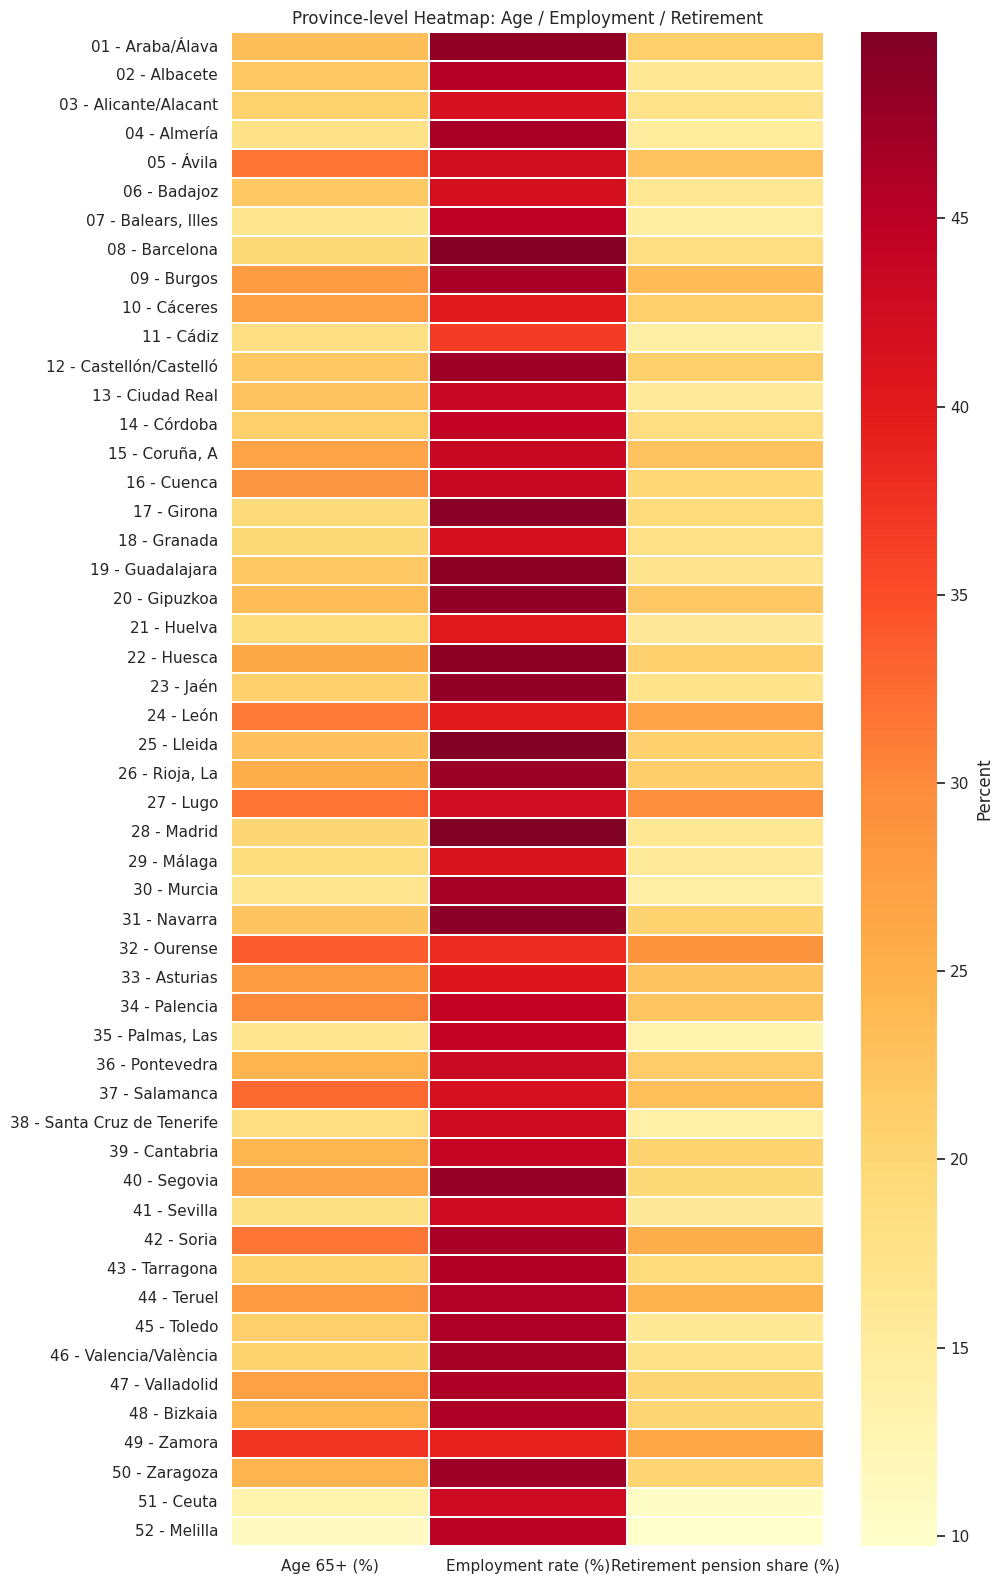

In [24]:
prov = (
    df.groupby(["prov_code_int", "prov_name"], as_index=False)
      [[c + "_pct" for c in metrics.keys()]]
      .mean()
)

prov = prov.rename(columns={c + "_pct": n for c, n in metrics.items()})
prov["label"] = prov["prov_code_int"].astype(str).str.zfill(2) + " - " + prov["prov_name"]
prov = prov.sort_values("prov_code_int")

plt.figure(figsize=(10, 16))
sns.heatmap(
    prov.set_index("label")[list(metrics.values())],
    cmap="YlOrRd",
    linewidths=0.2,
    cbar_kws={"label": "Percent"}
)
plt.title("Province-level Heatmap: Age / Employment / Retirement")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

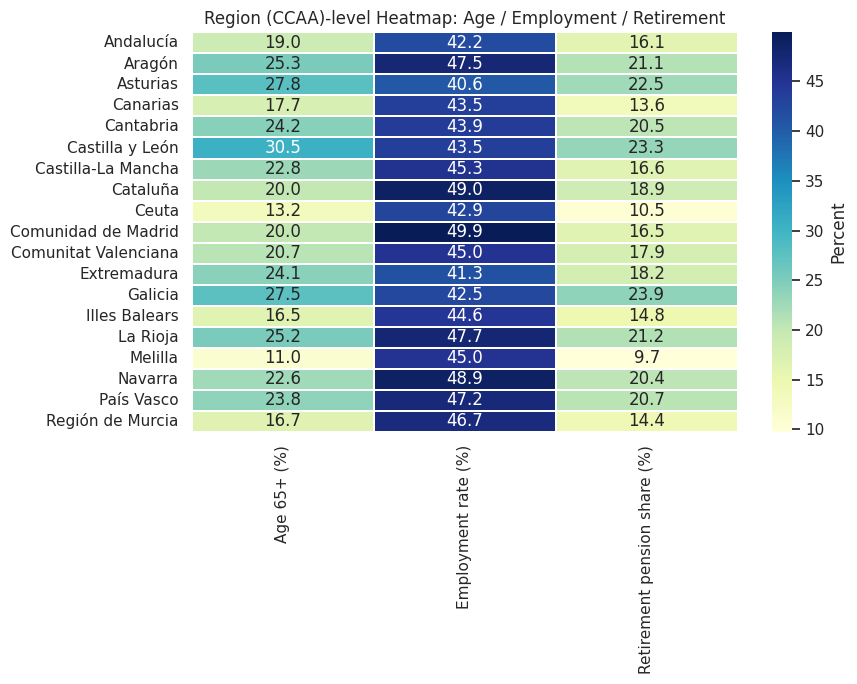

In [25]:
reg = (
    df.groupby("region", as_index=False)
      [[c + "_pct" for c in metrics.keys()]]
      .mean()
      .rename(columns={c + "_pct": n for c, n in metrics.items()})
      .sort_values("region")
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    reg.set_index("region")[list(metrics.values())],
    annot=True, fmt=".1f",
    cmap="YlGnBu",
    linewidths=0.3,
    cbar_kws={"label": "Percent"}
)
plt.title("Region (CCAA)-level Heatmap: Age / Employment / Retirement")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

In [26]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style="whitegrid")

# Province -> Region mapping (CCAA)
prov_to_region = {
    "Álava":"País Vasco","Albacete":"Castilla-La Mancha","Alicante/Alacant":"Comunitat Valenciana",
    "Almería":"Andalucía","Asturias":"Asturias","Ávila":"Castilla y León","Badajoz":"Extremadura",
    "Illes Balears":"Illes Balears","Barcelona":"Cataluña","Burgos":"Castilla y León","Cáceres":"Extremadura",
    "Cádiz":"Andalucía","Cantabria":"Cantabria","Castellón/Castelló":"Comunitat Valenciana",
    "Ciudad Real":"Castilla-La Mancha","Córdoba":"Andalucía","A Coruña":"Galicia","Cuenca":"Castilla-La Mancha",
    "Girona":"Cataluña","Granada":"Andalucía","Guadalajara":"Castilla-La Mancha","Gipuzkoa":"País Vasco",
    "Huelva":"Andalucía","Huesca":"Aragón","Jaén":"Andalucía","León":"Castilla y León","Lleida":"Cataluña",
    "Lugo":"Galicia","Madrid":"Comunidad de Madrid","Málaga":"Andalucía","Murcia":"Región de Murcia",
    "Navarra":"Navarra","Ourense":"Galicia","Palencia":"Castilla y León","Las Palmas":"Canarias",
    "Pontevedra":"Galicia","La Rioja":"La Rioja","Salamanca":"Castilla y León",
    "Santa Cruz de Tenerife":"Canarias","Segovia":"Castilla y León","Sevilla":"Andalucía",
    "Soria":"Castilla y León","Tarragona":"Cataluña","Teruel":"Aragón","Toledo":"Castilla-La Mancha",
    "Valencia/València":"Comunitat Valenciana","Valladolid":"Castilla y León","Bizkaia":"País Vasco",
    "Zamora":"Castilla y León","Zaragoza":"Aragón","Ceuta":"Ceuta","Melilla":"Melilla"
}

# Approx. annual mean temperatures (°C), province capitals reference-style
temp_data = [
("Álava",11.5),("Albacete",13.5),("Alicante/Alacant",18.3),("Almería",19.1),("Asturias",14.0),
("Ávila",10.6),("Badajoz",17.2),("Illes Balears",17.9),("Barcelona",16.8),("Burgos",11.0),
("Cáceres",16.1),("Cádiz",19.0),("Cantabria",14.3),("Castellón/Castelló",17.5),("Ciudad Real",15.8),
("Córdoba",18.7),("A Coruña",14.7),("Cuenca",12.9),("Girona",15.7),("Granada",16.0),
("Guadalajara",13.1),("Gipuzkoa",14.8),("Huelva",18.4),("Huesca",14.2),("Jaén",17.1),
("León",11.7),("Lleida",14.5),("Lugo",12.7),("Madrid",15.5),("Málaga",18.9),
("Murcia",18.0),("Navarra",13.6),("Ourense",14.8),("Palencia",12.0),("Las Palmas",21.0),
("Pontevedra",15.2),("La Rioja",13.9),("Salamanca",12.0),("Santa Cruz de Tenerife",22.0),
("Segovia",11.8),("Sevilla",19.2),("Soria",11.1),("Tarragona",17.3),("Teruel",12.7),
("Toledo",16.2),("Valencia/València",18.2),("Valladolid",12.6),("Bizkaia",14.9),
("Zamora",13.0),("Zaragoza",15.4),("Ceuta",18.6),("Melilla",19.3)
]

prov_temp = pd.DataFrame(temp_data, columns=["province","mean_temp_c"])
prov_temp["region"] = prov_temp["province"].map(prov_to_region)

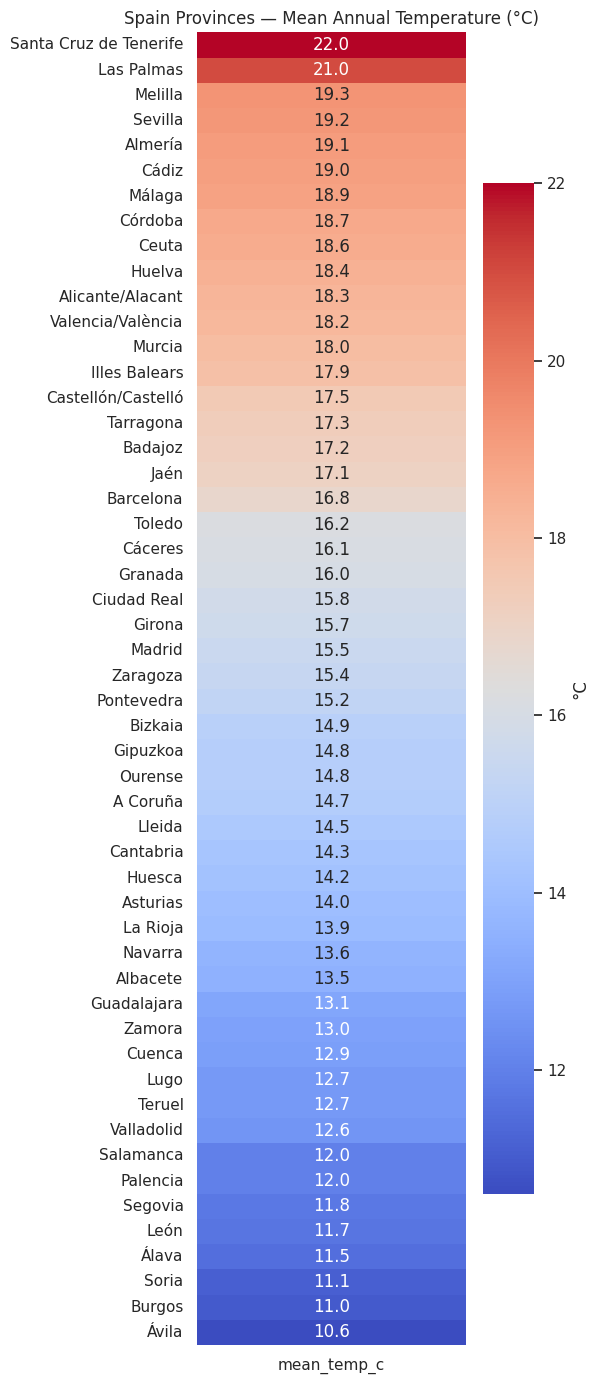

In [27]:
prov_heat = prov_temp.sort_values("mean_temp_c", ascending=False).set_index("province")[["mean_temp_c"]]

plt.figure(figsize=(6, 14))
sns.heatmap(prov_heat, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label":"°C"})
plt.title("Spain Provinces — Mean Annual Temperature (°C)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()

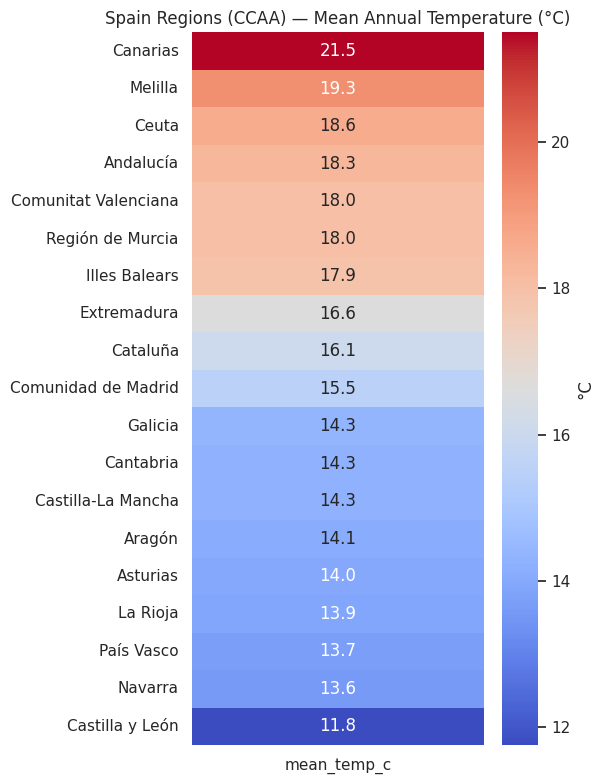

In [28]:
reg_temp = (
    prov_temp.groupby("region", as_index=False)["mean_temp_c"]
    .mean()
    .sort_values("mean_temp_c", ascending=False)
    .set_index("region")[["mean_temp_c"]]
)

plt.figure(figsize=(6, 8))
sns.heatmap(reg_temp, annot=True, fmt=".1f", cmap="coolwarm", cbar_kws={"label":"°C"})
plt.title("Spain Regions (CCAA) — Mean Annual Temperature (°C)")
plt.xlabel("")
plt.ylabel("")
plt.tight_layout()
plt.show()